In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, VotingRegressor, BaggingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib


In [31]:
df = pd.read_csv('Life Expectancy Data.csv')
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [33]:
df = df.rename(columns=lambda x: x.strip().replace(' ', '_').replace('-', '_').title())
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life_Expectancy                  2928 non-null   float64
 4   Adult_Mortality                  2928 non-null   float64
 5   Infant_Deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   Percentage_Expenditure           2938 non-null   float64
 8   Hepatitis_B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  Bmi                              2904 non-null   float64
 11  Under_Five_Deaths                2938 non-null   int64  
 12  Polio                          

In [34]:
# Removing leading & trailing spaces from data
df = df.apply(lambda x: x.str.strip().str.title() if x.dtype == "str" else x)

In [35]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life_Expectancy                     10
Adult_Mortality                     10
Infant_Deaths                        0
Alcohol                            194
Percentage_Expenditure               0
Hepatitis_B                        553
Measles                              0
Bmi                                 34
Under_Five_Deaths                    0
Polio                               19
Total_Expenditure                  226
Diphtheria                          19
Hiv/Aids                             0
Gdp                                448
Population                         652
Thinness__1_19_Years                34
Thinness_5_9_Years                  34
Income_Composition_Of_Resources    167
Schooling                          163
dtype: int64

In [ ]:
# Drop rows with missing target variable
df.dropna(subset=['Life_Expectancy'], inplace=True)

# Removing 'Year' column as it is not relevant for prediction
# Removing 'Country' column as it is adding same value as "Status" column in prediction
df.drop(["Year", "Country"], axis=1, inplace=True)

In [37]:
df.isnull().sum()

Status                               0
Life_Expectancy                      0
Adult_Mortality                      0
Infant_Deaths                        0
Alcohol                            193
Percentage_Expenditure               0
Hepatitis_B                        553
Measles                              0
Bmi                                 32
Under_Five_Deaths                    0
Polio                               19
Total_Expenditure                  226
Diphtheria                          19
Hiv/Aids                             0
Gdp                                443
Population                         644
Thinness__1_19_Years                32
Thinness_5_9_Years                  32
Income_Composition_Of_Resources    160
Schooling                          160
dtype: int64

In [38]:
# Fill missing values with mean
df["Alcohol"] = df["Alcohol"].fillna(df["Alcohol"].mean(), inplace=True)
df["Hepatitis_B"] = df["Hepatitis_B"].fillna(df["Hepatitis_B"].mean(), inplace=True)
df["Bmi"] = df["Bmi"].fillna(df["Bmi"].mean(), inplace=True)
df["Polio"] = df["Polio"].fillna(df["Polio"].mean(), inplace=True)
df["Total_Expenditure"] = df["Total_Expenditure"].fillna(df["Total_Expenditure"].mean(), inplace=True)
df["Diphtheria"] = df["Diphtheria"].fillna(df["Diphtheria"].mean(), inplace=True)
df["Gdp"] = df["Gdp"].fillna(df["Gdp"].mean(), inplace=True)
df["Population"] = df["Population"].fillna(df["Population"].mean(), inplace=True)
df["Thinness__1_19_Years"] = df["Thinness__1_19_Years"].fillna(df["Thinness__1_19_Years"].mean(), inplace=True)
df["Thinness_5_9_Years"] = df["Thinness_5_9_Years"].fillna(df["Thinness_5_9_Years"].mean(), inplace=True)
df["Income_Composition_Of_Resources"] = df["Income_Composition_Of_Resources"].fillna(df["Income_Composition_Of_Resources"].mean(), inplace=True)
df["Schooling"] = df["Schooling"].fillna(df["Schooling"].mean(), inplace=True)

In [39]:
df.isnull().sum()

Status                             0
Life_Expectancy                    0
Adult_Mortality                    0
Infant_Deaths                      0
Alcohol                            0
Percentage_Expenditure             0
Hepatitis_B                        0
Measles                            0
Bmi                                0
Under_Five_Deaths                  0
Polio                              0
Total_Expenditure                  0
Diphtheria                         0
Hiv/Aids                           0
Gdp                                0
Population                         0
Thinness__1_19_Years               0
Thinness_5_9_Years                 0
Income_Composition_Of_Resources    0
Schooling                          0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Life_Expectancy,2928.0,6.922493e+01,9.523867e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
Adult_Mortality,2928.0,1.647964e+02,1.242921e+02,1.00000,74.000000,1.440000e+02,2.280000e+02,7.230000e+02
Infant_Deaths,2928.0,3.040745e+01,1.181144e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
Alcohol,2928.0,4.614856e+00,3.914923e+00,0.01000,1.107500,4.160000e+00,7.400000e+00,1.787000e+01
Percentage_Expenditure,2928.0,7.403212e+02,1.990931e+03,0.00000,4.853964,6.561145e+01,4.426143e+02,1.947991e+04
Hepatitis_B,2928.0,8.096084e+01,2.253136e+01,1.00000,80.960842,8.700000e+01,9.600000e+01,9.900000e+01
Measles,2928.0,2.427856e+03,1.148597e+04,0.00000,0.000000,1.700000e+01,3.622500e+02,2.121830e+05
Bmi,2928.0,3.823539e+01,1.985018e+01,1.00000,19.400000,4.300000e+01,5.610000e+01,7.760000e+01
Under_Five_Deaths,2928.0,4.217930e+01,1.607005e+02,0.00000,0.000000,4.000000e+00,2.800000e+01,2.500000e+03
Polio,2928.0,8.254830e+01,2.334055e+01,3.00000,78.000000,9.300000e+01,9.700000e+01,9.900000e+01


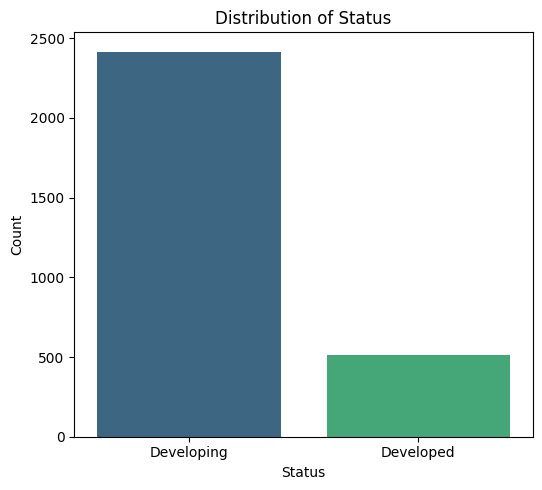

In [42]:
# Visualize the distribution of categorical variables
categorical_cols = df.select_dtypes(include='object').columns

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=df[col], palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

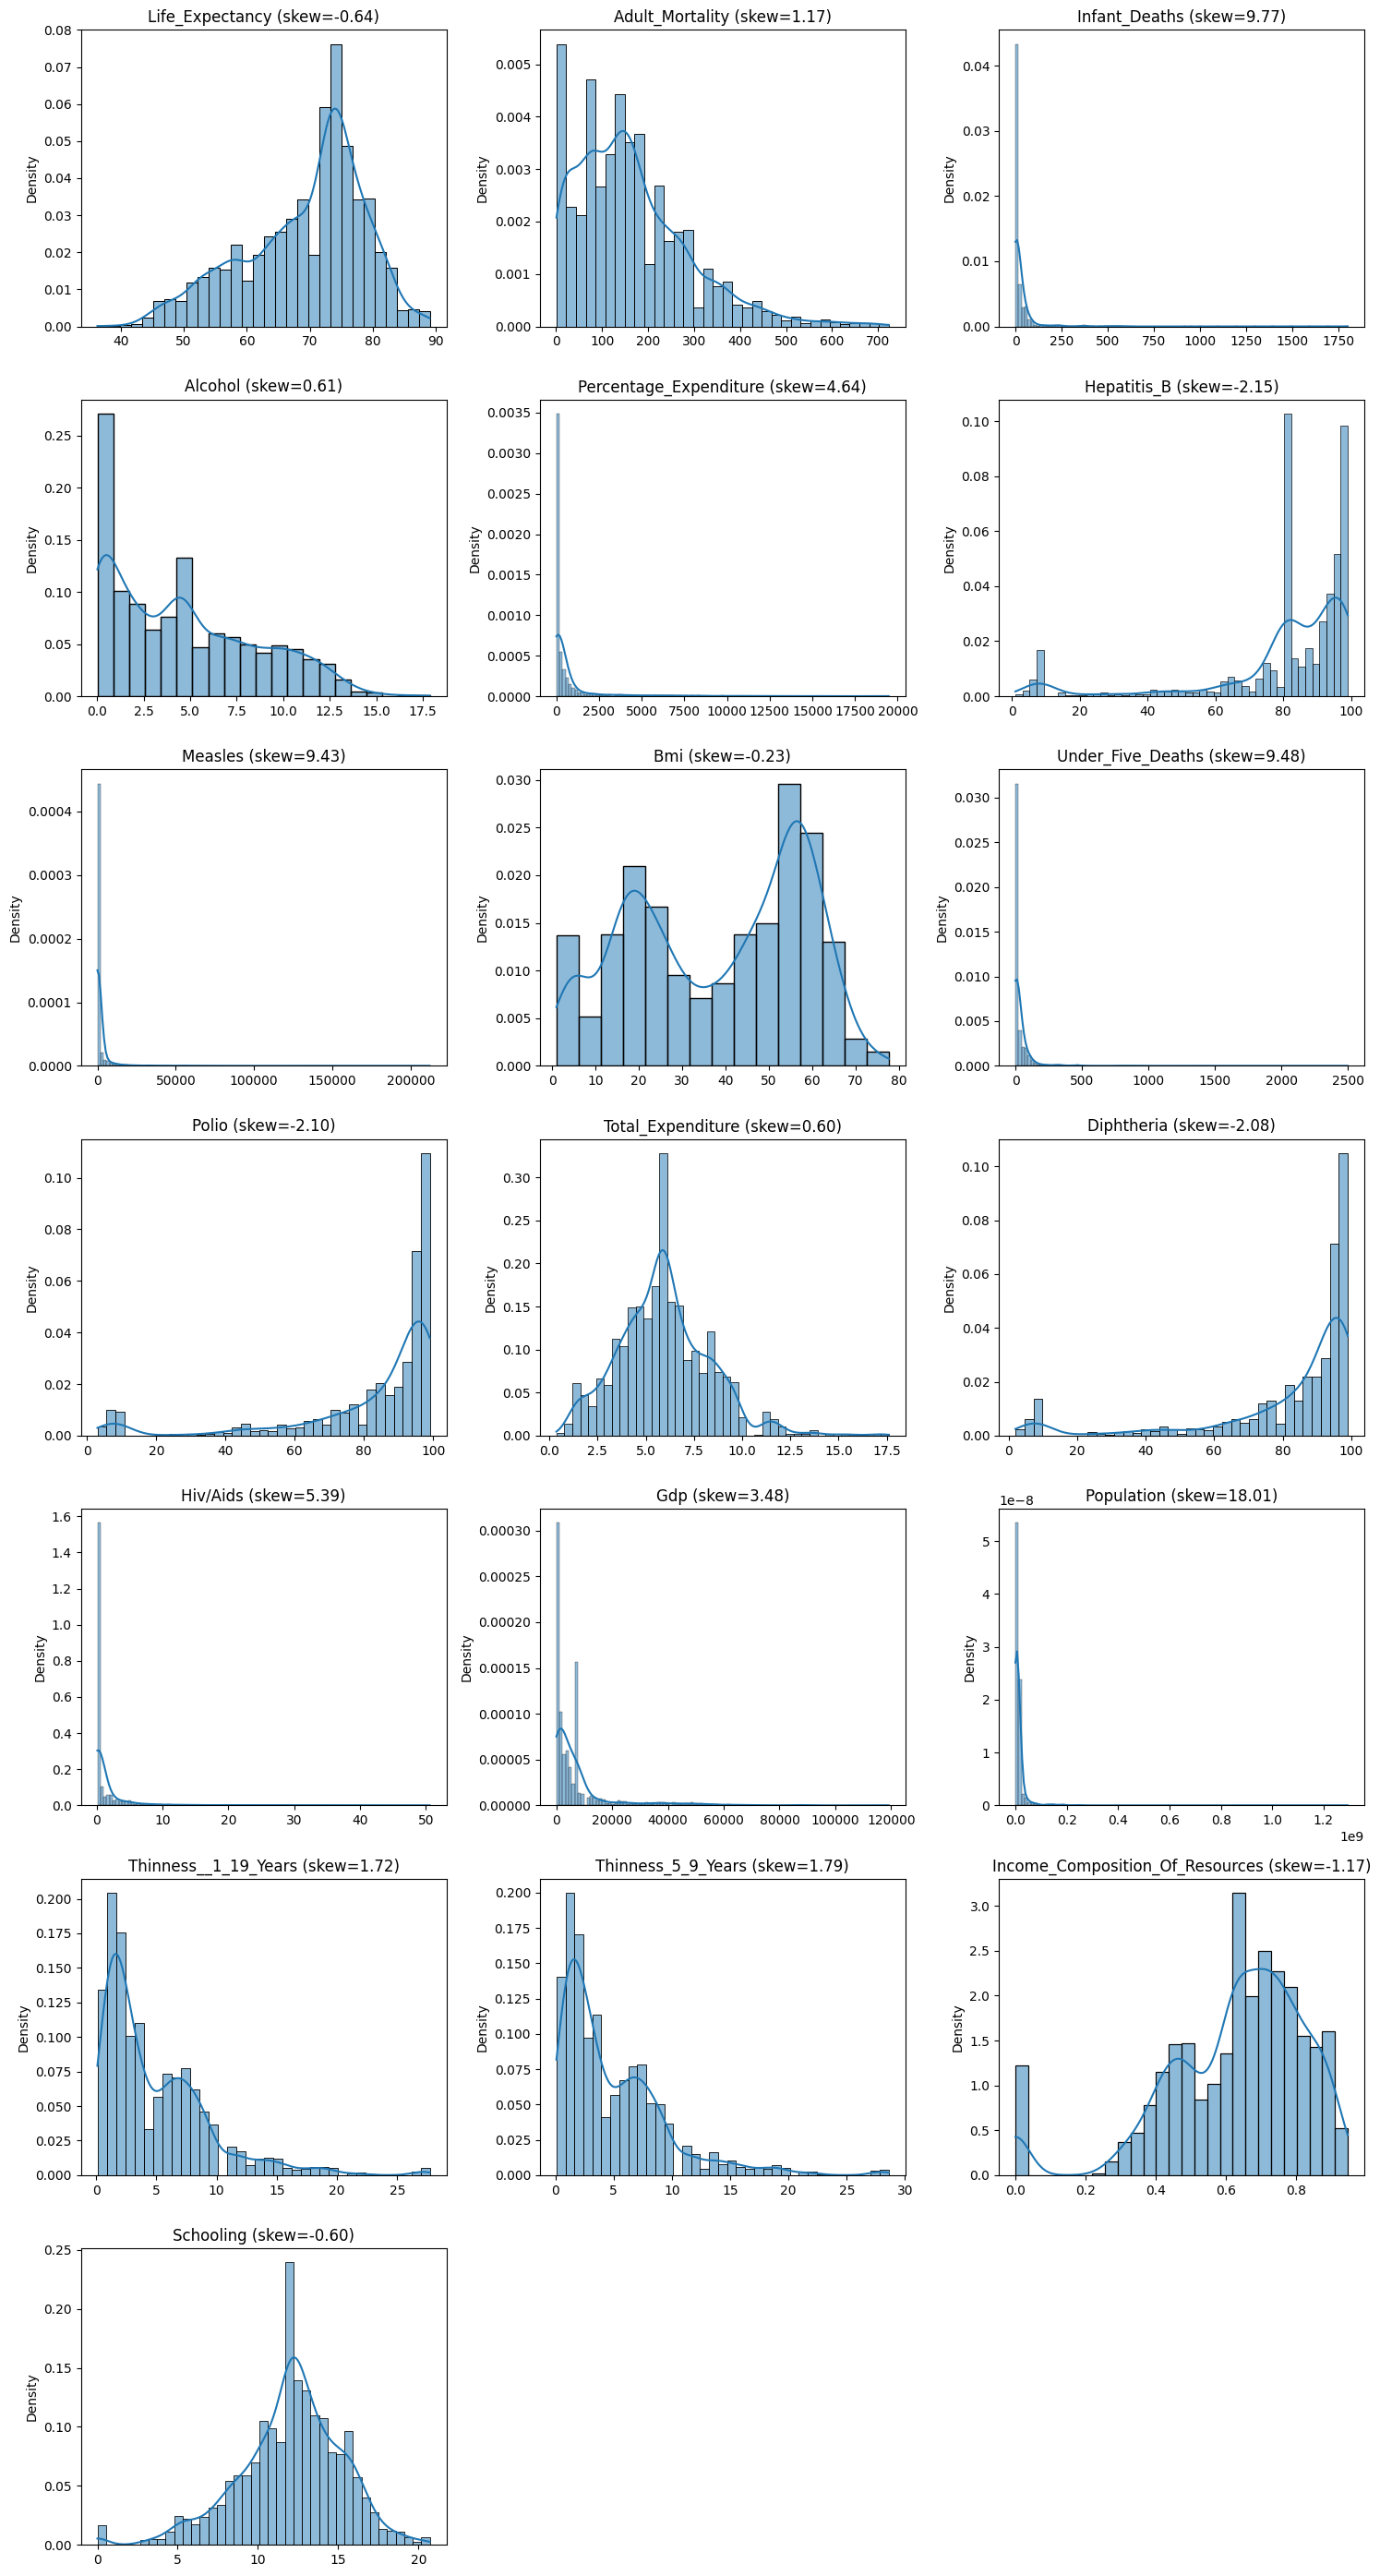

In [43]:
# Visualize the distribution of numerical variables
numerical_cols = df.select_dtypes(include=np.number).columns
n = len(numerical_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 5, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], stat='density', color='C0')
    axes[i].set_title(f'{col} (skew={df[col].skew():.2f})')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')

# remove any unused axes
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

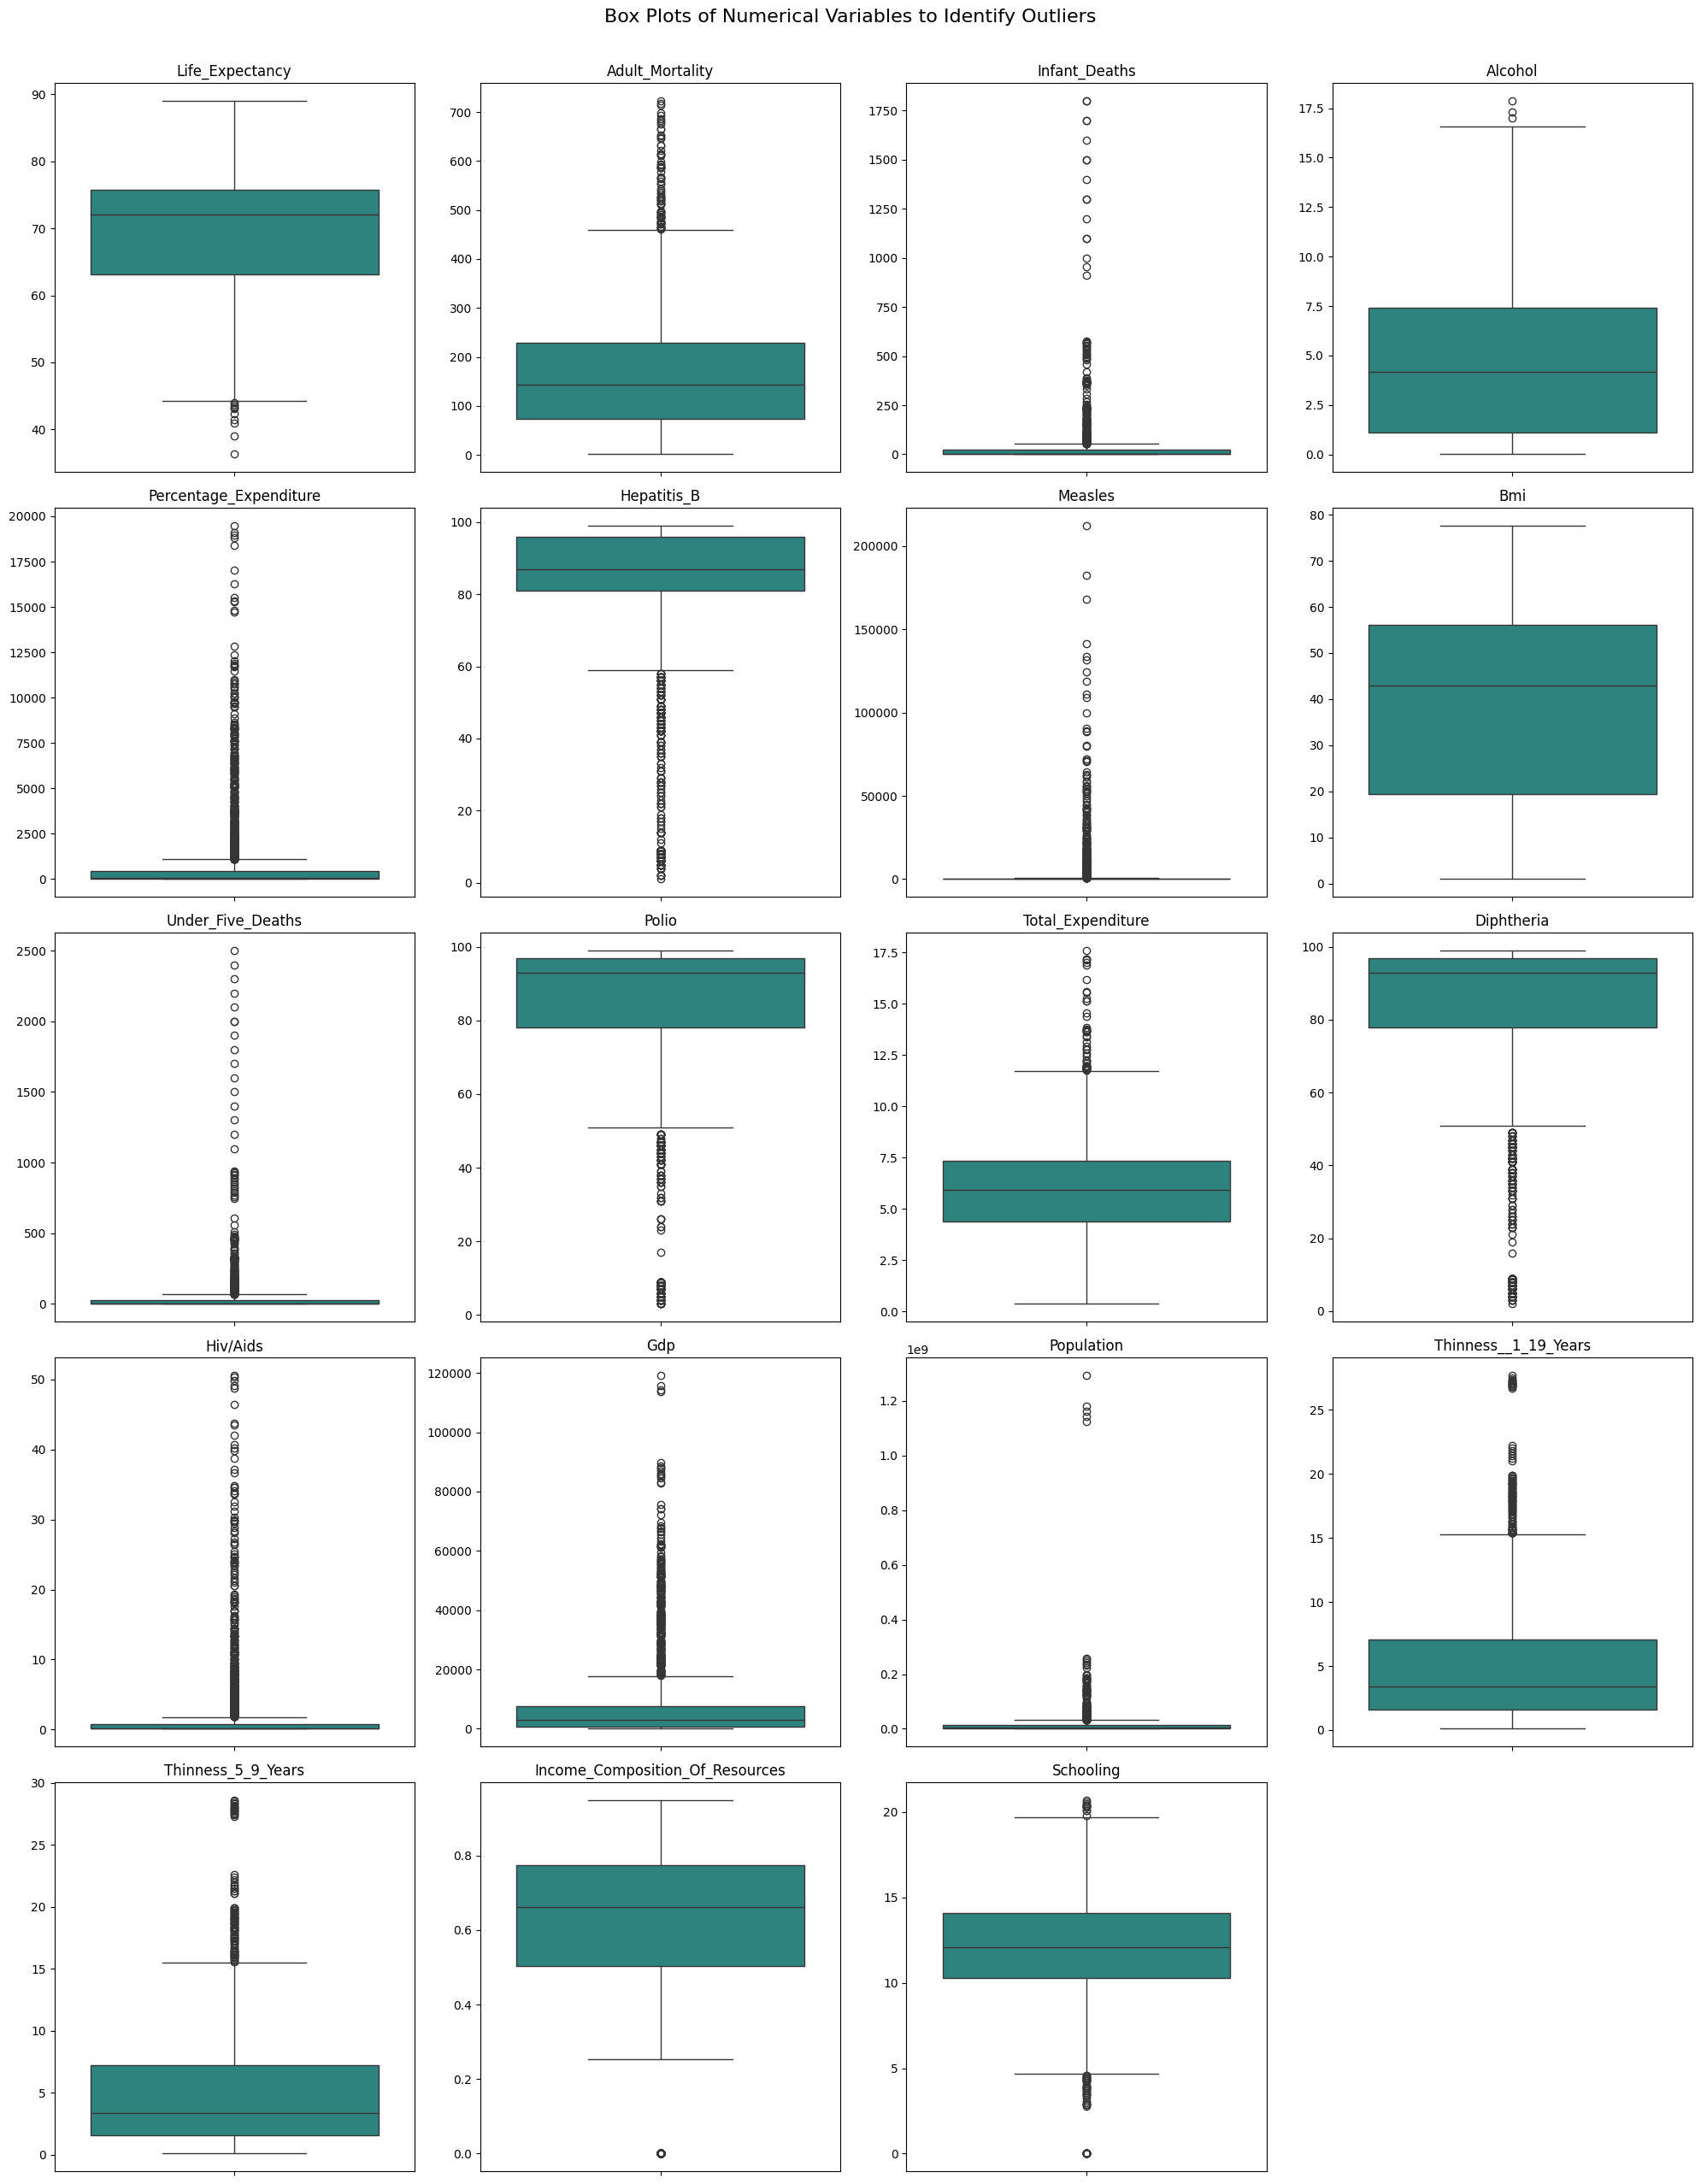

In [44]:
# Visualize the box plots for numerical variables
num_plots = len(numerical_cols)
num_rows = (num_plots + 3) // 4  # Adjust for 4 plots per row
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('') # Remove y-label for cleaner look
    axes[i].tick_params(axis='y', labelsize=10)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables to Identify Outliers', y=1.02, fontsize=16)
plt.show()

In [ ]:
# convert categorical to numeric
#label_encoders = {}

#for col in categorical_cols:
#    label_encoders[col] = LabelEncoder()
#    df[col] = label_encoders[col].fit_transform(df[col])
#    print({label: index for index, label in enumerate(label_encoders[col].classes_)})

In [45]:
# convert categorical to numeric using one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols, dtype=int, drop_first=True)

In [46]:
df.columns

Index(['Life_Expectancy', 'Adult_Mortality', 'Infant_Deaths', 'Alcohol',
       'Percentage_Expenditure', 'Hepatitis_B', 'Measles', 'Bmi',
       'Under_Five_Deaths', 'Polio', 'Total_Expenditure', 'Diphtheria',
       'Hiv/Aids', 'Gdp', 'Population', 'Thinness__1_19_Years',
       'Thinness_5_9_Years', 'Income_Composition_Of_Resources', 'Schooling',
       'Status_Developing'],
      dtype='str')

In [47]:
df.rename(columns={'Status_Developing': 'Status'}, inplace=True)

In [48]:
df.head()

,Life_Expectancy,Adult_Mortality,Infant_Deaths,Alcohol,Percentage_Expenditure,Hepatitis_B,Measles,Bmi,Under_Five_Deaths,Polio,Total_Expenditure,Diphtheria,Hiv/Aids,Gdp,Population,Thinness__1_19_Years,Thinness_5_9_Years,Income_Composition_Of_Resources,Schooling,Status
0,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,1
1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,1
2,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,1
3,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,1
4,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,1


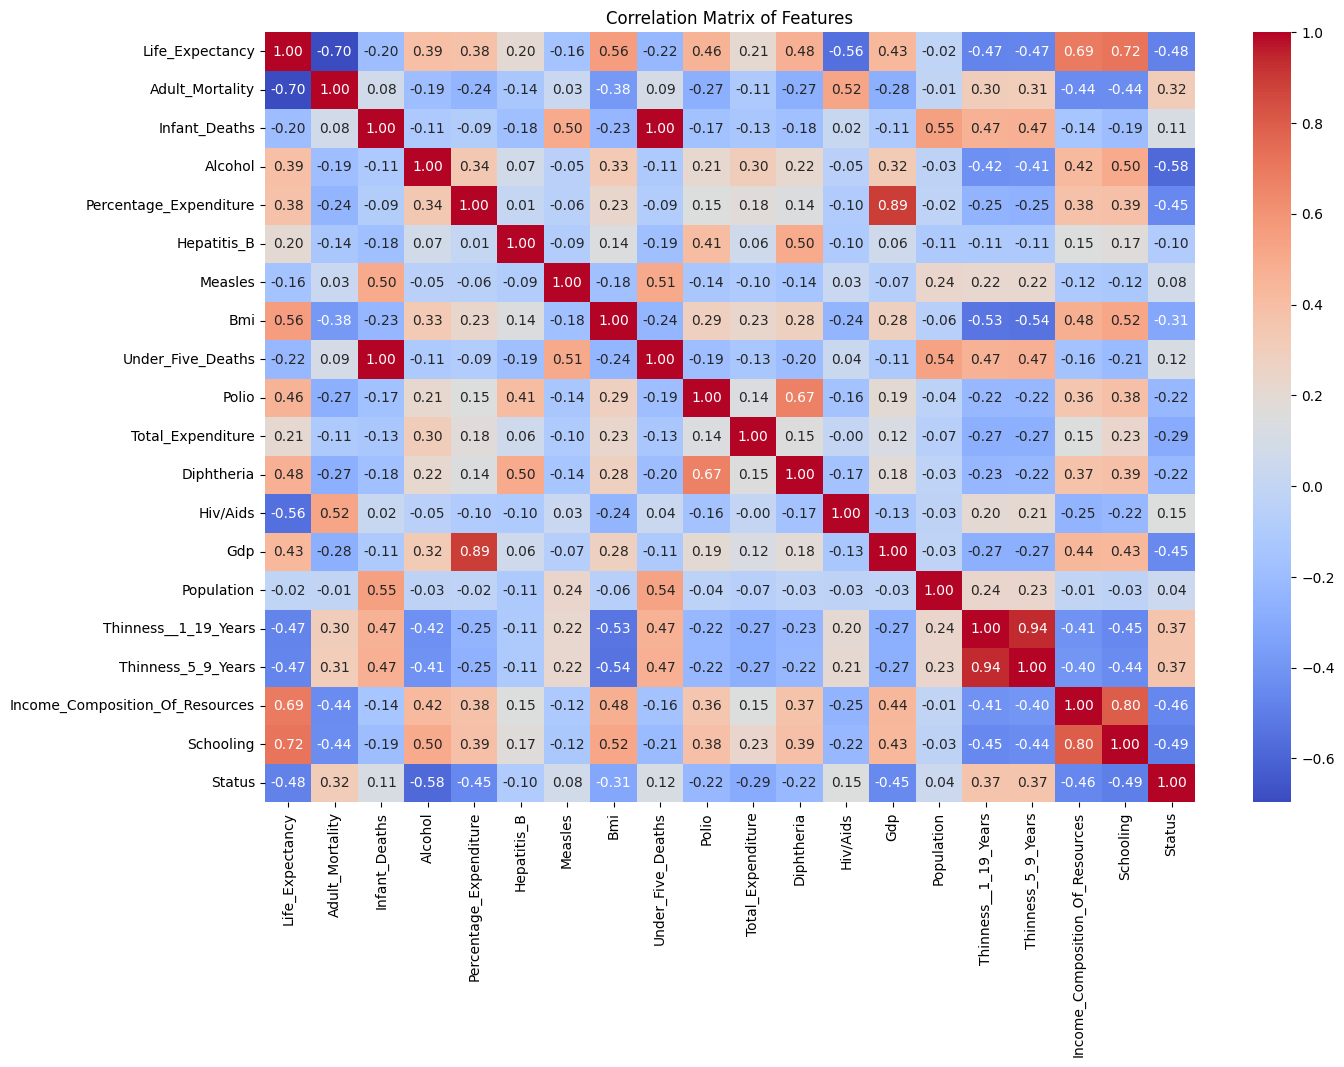

In [49]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

In [50]:
df.skew()

Life_Expectancy                    -0.638605
Adult_Mortality                     1.174369
Infant_Deaths                       9.771044
Alcohol                             0.607622
Percentage_Expenditure              4.643790
Hepatitis_B                        -2.146879
Measles                             9.425290
Bmi                                -0.231828
Under_Five_Deaths                   9.479623
Polio                              -2.104791
Total_Expenditure                   0.600863
Diphtheria                         -2.079352
Hiv/Aids                            5.386623
Gdp                                 3.476242
Population                         18.010899
Thinness__1_19_Years                1.720041
Thinness_5_9_Years                  1.786369
Income_Composition_Of_Resources    -1.174653
Schooling                          -0.600505
Status                             -1.712798
dtype: float64

#### Observations :
##### i. The dataset contains 2938 unique entries, with few missing values.
##### ii. Removed rows with missing value in target variable. Other missising values replaced with mean of that variable. 
##### iii. More data entries for "Developing" countries than "Developed" contries.
##### iv. Removed "Country" & "Year" columns as they are not relavant for prediction.
##### v. Predictors other than Bmi are skewed.

#### Function to evaluate model performance

In [51]:
training_r2_scores = []
testing_r2_scores = []
training_adj_r2_scores = []
testing_adj_r2_scores = []
training_rmse_scores = []
testing_rmse_scores = []
overfitting_status = []
overfitting_threshold = 0.05

def ClearMetrics():
    training_r2_scores.clear()
    testing_r2_scores.clear()
    training_adj_r2_scores.clear()
    testing_adj_r2_scores.clear()
    training_rmse_scores.clear()
    testing_rmse_scores.clear()
    overfitting_status.clear()

def EvaluateModel(p_model, p_x_train, p_y_train, p_x_test, p_y_test):
    p_model.fit(p_x_train, p_y_train)
    
    y_train_pred = p_model.predict(p_x_train)
    train_mse = mean_squared_error(p_y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_mae = mean_absolute_error(p_y_train, y_train_pred)
    train_r2 = r2_score(p_y_train, y_train_pred)
    train_adj_r2 = 1 - (1 - train_r2) * (len(p_y_train) - 1) / (len(p_y_train) - p_x_train.shape[1] - 1)

    y_test_pred = p_model.predict(p_x_test)
    test_mse = mean_squared_error(p_y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(p_y_test, y_test_pred)
    test_r2 = r2_score(p_y_test, y_test_pred)
    test_adj_r2 = 1 - (1 - test_r2) * (len(p_y_test) - 1) / (len(p_y_test) - p_x_test.shape[1] - 1)

    training_r2_scores.append(np.round(train_r2, 4))
    testing_r2_scores.append(np.round(test_r2, 4))
    training_adj_r2_scores.append(np.round(train_adj_r2, 4))
    testing_adj_r2_scores.append(np.round(test_adj_r2, 4))
    training_rmse_scores.append(np.round(train_rmse, 4))
    testing_rmse_scores.append(np.round(test_rmse, 4))
    overfitting_status.append("Y" if abs(train_r2 - test_r2) > overfitting_threshold else "N")

In [52]:
def EndToEndEvaluation(p_models, p_x_train, p_y_train, p_x_test, p_y_test):
    ClearMetrics()
    for l_model in p_models:
        EvaluateModel(l_model, p_x_train, p_y_train, p_x_test, p_y_test)

    results_df = pd.DataFrame({
        'Model': [model.__class__.__name__ for model in p_models],
        'Train R2': training_r2_scores,
        'Test R2': testing_r2_scores,
        'Train Adjusted R2': training_adj_r2_scores,
        'Test Adjusted R2': testing_adj_r2_scores,
        'Train RMSE': training_rmse_scores,
        'Test RMSE': testing_rmse_scores,
        'Overfitting (Y/N)': overfitting_status
    })

    results_df = results_df.sort_values(by='Test R2', ascending=False).reset_index(drop=True)
    return results_df

In [53]:
models = [
    LinearRegression(),
    Ridge(),
    Lasso(),
    ElasticNet(),
    DecisionTreeRegressor(random_state=42),
    RandomForestRegressor(random_state=42),
    SVR(),
    KNeighborsRegressor(),
    GradientBoostingRegressor(random_state=42),
    AdaBoostRegressor(random_state=42),
    XGBRegressor(random_state=42),
    VotingRegressor(estimators=[
        ('lr', LinearRegression()),
        ('svr', SVR()),
        ('knn', KNeighborsRegressor()),
        ('rf', RandomForestRegressor(random_state=42))
    ])
]

#### Evaluate without EDA

In [54]:
df_without_eda = df.copy()

x = df_without_eda.drop(columns=['Life_Expectancy'])
y = df_without_eda['Life_Expectancy']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Model evaluation without EDA :")
EndToEndEvaluation(models, x_train, y_train, x_test, y_test)

Model evaluation without EDA :


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE,Overfitting (Y/N)
0,RandomForestRegressor,0.9946,0.9669,0.9945,0.9658,0.7063,1.6930,N
1,XGBRegressor,0.9991,0.9620,0.9991,0.9607,0.2918,1.8135,N
2,GradientBoostingRegressor,0.9610,0.9482,0.9607,0.9465,1.8907,2.1165,N
3,DecisionTreeRegressor,1.0000,0.9315,1.0000,0.9293,0.0000,2.4333,Y
4,AdaBoostRegressor,0.9032,0.8931,0.9024,0.8895,2.9791,3.0409,N
5,Ridge,0.8199,0.8206,0.8184,0.8145,4.0637,3.9398,N
6,ElasticNet,0.8113,0.8074,0.8097,0.8009,4.1599,4.0822,N
7,Lasso,0.8099,0.8071,0.8084,0.8007,4.1744,4.0844,N
8,VotingRegressor,0.7051,0.6339,0.7027,0.6216,5.1998,5.6273,Y
9,LinearRegression,0.5798,0.5720,0.5764,0.5577,6.2067,6.0843,N


#### Perform EDA

In [ ]:
df_eda = df.copy()

In [79]:
df_eda.skew()

Life_Expectancy                    -0.638605
Adult_Mortality                     1.174369
Infant_Deaths                       9.771044
Alcohol                             0.607622
Percentage_Expenditure              4.643790
Hepatitis_B                        -2.146879
Measles                             9.425290
Bmi                                -0.231828
Under_Five_Deaths                   9.479623
Polio                              -2.104791
Total_Expenditure                   0.600863
Diphtheria                         -2.079352
Hiv/Aids                            5.386623
Gdp                                 3.476242
Population                         18.010899
Thinness__1_19_Years                1.720041
Thinness_5_9_Years                  1.786369
Income_Composition_Of_Resources    -1.174653
Schooling                          -0.600505
Status                             -1.712798
dtype: float64

In [80]:
skewed_cols = [col for col in df_eda.columns if ((df_eda[col].skew() > 0.5 or df_eda[col].skew() < -0.5) and col not in ['Status', 'Life_Expectancy'])]
skewed_cols

['Adult_Mortality',
 'Infant_Deaths',
 'Alcohol',
 'Percentage_Expenditure',
 'Hepatitis_B',
 'Measles',
 'Under_Five_Deaths',
 'Polio',
 'Total_Expenditure',
 'Diphtheria',
 'Hiv/Aids',
 'Gdp',
 'Population',
 'Thinness__1_19_Years',
 'Thinness_5_9_Years',
 'Income_Composition_Of_Resources',
 'Schooling']

In [81]:
PowerTransformers = {}

for col in skewed_cols:
    pt = PowerTransformer(method='yeo-johnson', standardize=True)
    df_eda[col] = pt.fit_transform(df_eda[[col]])
    PowerTransformers[col] = pt

In [82]:
df_eda.skew()

Life_Expectancy                   -0.638605
Adult_Mortality                   -0.080304
Infant_Deaths                      0.173319
Alcohol                           -0.096194
Percentage_Expenditure            -0.014672
Hepatitis_B                       -0.875460
Measles                            0.178441
Bmi                               -0.231828
Under_Five_Deaths                  0.165568
Polio                             -1.018199
Total_Expenditure                  0.020257
Diphtheria                        -1.034009
Hiv/Aids                           0.965566
Gdp                               -0.027002
Population                        -0.047653
Thinness__1_19_Years               0.018580
Thinness_5_9_Years                 0.013503
Income_Composition_Of_Resources   -0.124907
Schooling                         -0.035232
Status                            -1.712798
dtype: float64

#### As both positive & negative skewness was present, used PowrTransformer to remove skewness

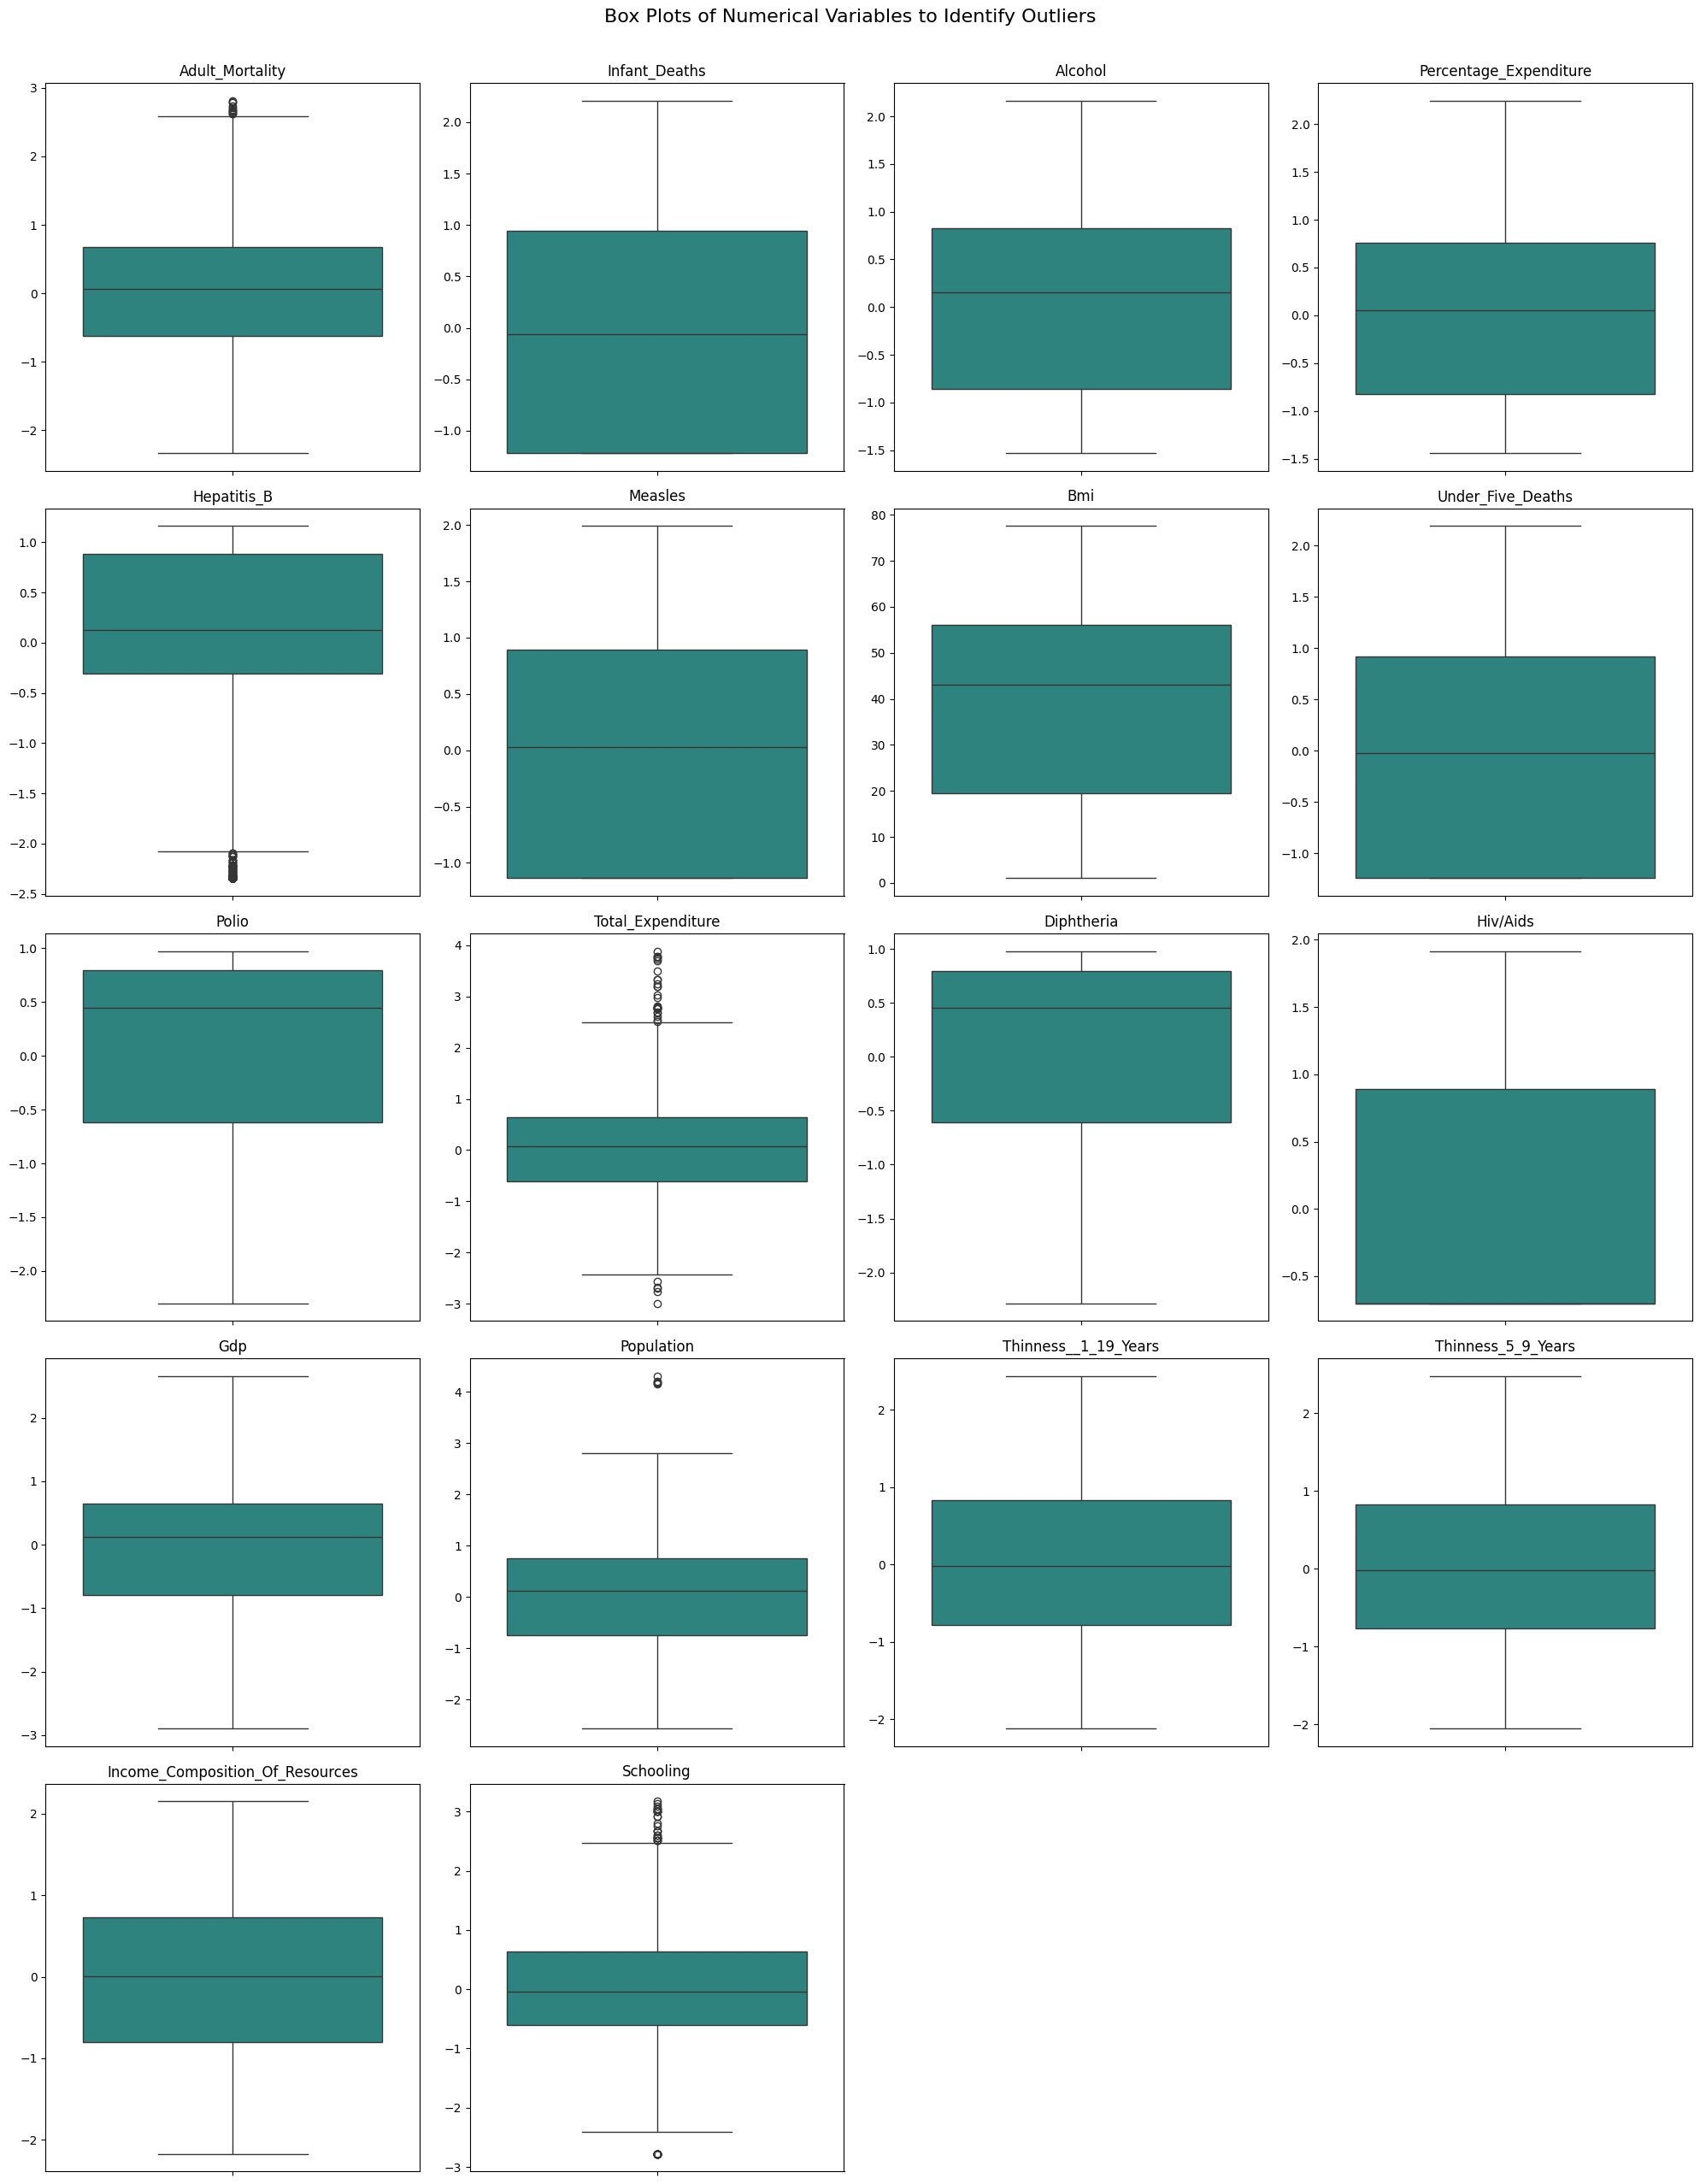

In [83]:
# outlier detection

predictors = [col for col in df_eda.columns if (col in numerical_cols and col not in ['Life_Expectancy'])]
num_plots = len(predictors)
num_rows = (num_plots + 3) // 4  # Adjust for 4 plots per row
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(predictors):
    sns.boxplot(y=df_eda[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('') # Remove y-label for cleaner look
    axes[i].tick_params(axis='y', labelsize=10)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables to Identify Outliers', y=1.02, fontsize=16)
plt.show()

In [84]:
def Get_iqr_bounds(p_df, p_column):
    Q1 = p_df[p_column].quantile(0.25)
    Q3 = p_df[p_column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    return lower_bound, upper_bound
    
def handle_outliers(p_df, p_column):
    lower_bound, upper_bound = Get_iqr_bounds(p_df, p_column)
    print("handle_outliers :: " + p_column + " : lower_bound : ", lower_bound, ", upper_bound : ", upper_bound)
    #capping values outside the bounds
    p_df[p_column] = np.where((p_df[p_column] < lower_bound), lower_bound, p_df[p_column])
    p_df[p_column] = np.where((p_df[p_column] > upper_bound), upper_bound, p_df[p_column])

def Get_outliers_percentage(p_df, p_column):
    lower_bound, upper_bound = Get_iqr_bounds(p_df, p_column)
    total_count = len(p_df)
    outliers_count = p_df[(p_df[p_column] < lower_bound) | (p_df[p_column] > upper_bound)].shape[0]
    outliers_percentage = (outliers_count / total_count) * 100
    print(f"Get_outliers_percentage :: {p_column} : Outliers Percentage: {outliers_percentage:.2f}% , outliers_count : {outliers_count} , total_count : {total_count}")
    return outliers_percentage

#Handling outliers by capping them using IQR method if outliers percentage is less than or equal to 5%
for col in predictors:
    if Get_outliers_percentage(df_eda, col) <= 5:
        handle_outliers(df_eda, col)

Get_outliers_percentage :: Adult_Mortality : Outliers Percentage: 0.38% , outliers_count : 11 , total_count : 2928
handle_outliers :: Adult_Mortality : lower_bound :  -2.5663827446545175 , upper_bound :  2.6141685840133073
Get_outliers_percentage :: Infant_Deaths : Outliers Percentage: 0.00% , outliers_count : 0 , total_count : 2928
handle_outliers :: Infant_Deaths : lower_bound :  -4.460101270098997 , upper_bound :  4.185465685505239
Get_outliers_percentage :: Alcohol : Outliers Percentage: 0.00% , outliers_count : 0 , total_count : 2928
handle_outliers :: Alcohol : lower_bound :  -3.3994770602501743 , upper_bound :  3.3670310745962335
Get_outliers_percentage :: Percentage_Expenditure : Outliers Percentage: 0.00% , outliers_count : 0 , total_count : 2928
handle_outliers :: Percentage_Expenditure : lower_bound :  -3.2037456026109377 , upper_bound :  3.1424567110832977
Get_outliers_percentage :: Hepatitis_B : Outliers Percentage: 7.14% , outliers_count : 209 , total_count : 2928
Get_out

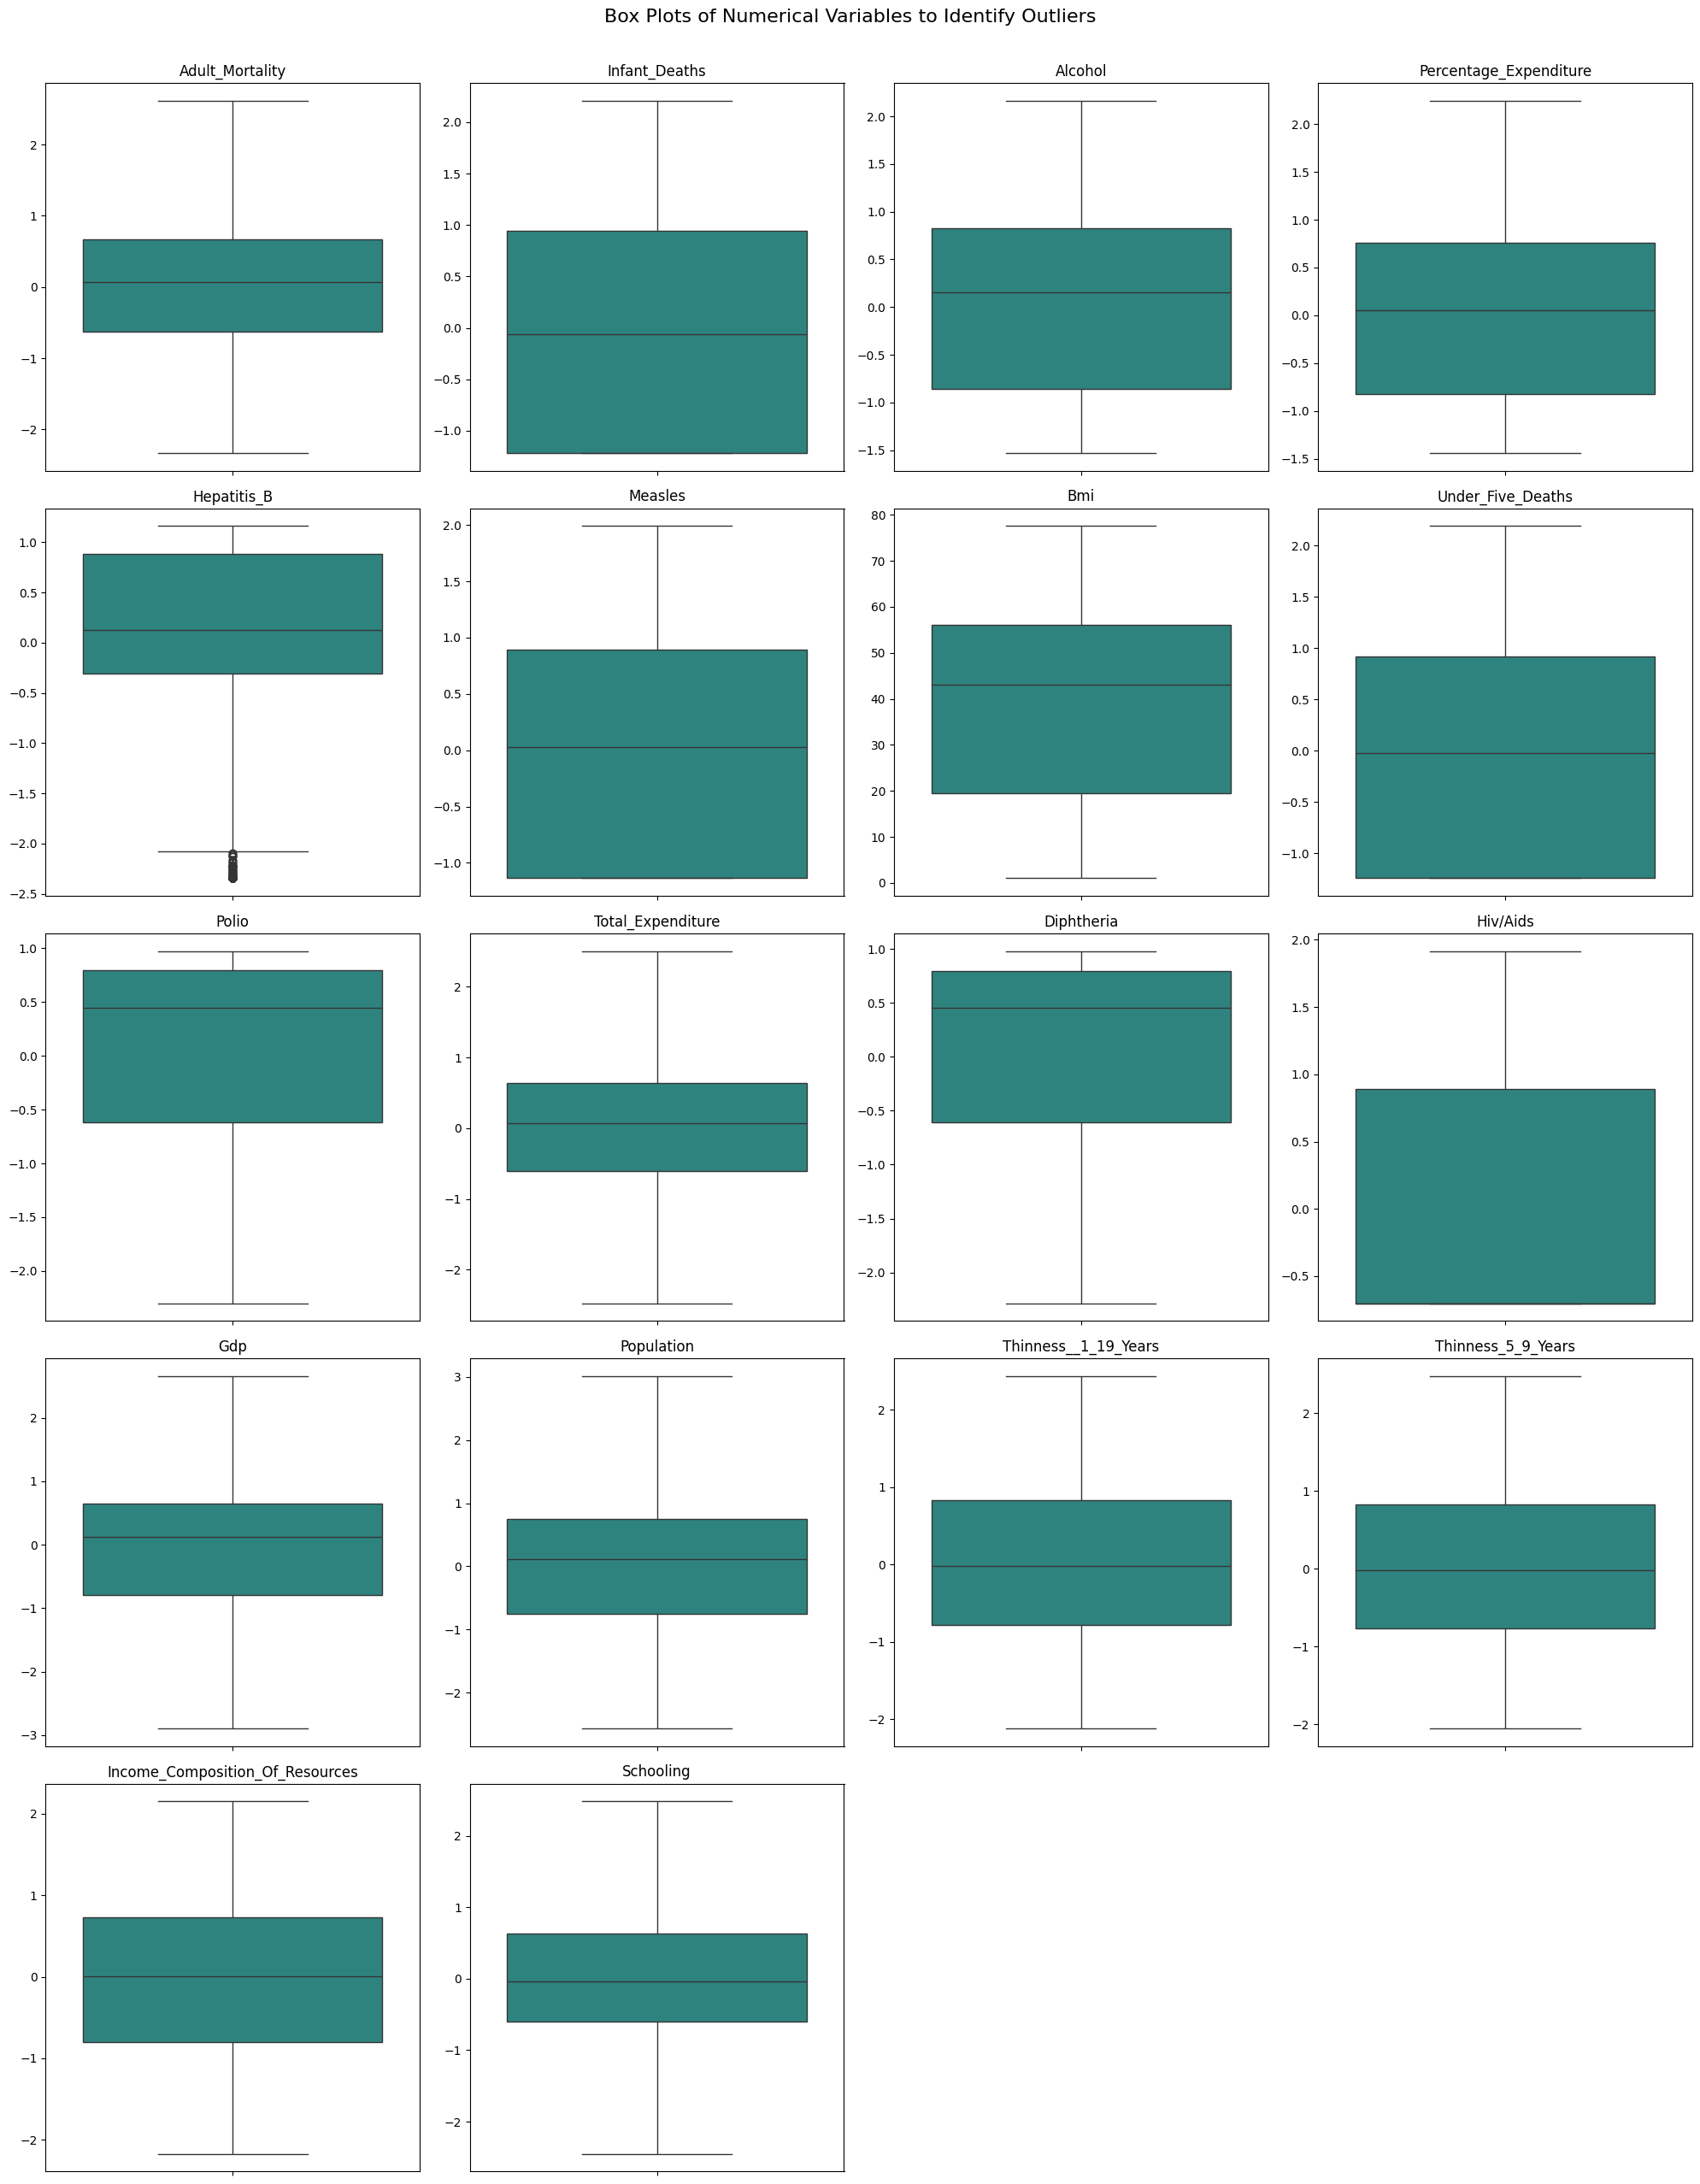

In [85]:
# distribution post outlier detection

num_plots = len(predictors)
num_rows = (num_plots + 3) // 4  # Adjust for 4 plots per row
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(predictors):
    sns.boxplot(y=df_eda[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('') # Remove y-label for cleaner look
    axes[i].tick_params(axis='y', labelsize=10)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables to Identify Outliers', y=1.02, fontsize=16)
plt.show()

In [86]:
df_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
Life_Expectancy,2928.0,6.922493e+01,9.523867,36.300000,63.100000,72.100000,75.700000,89.000000
Adult_Mortality,2928.0,-3.406416e-04,0.999256,-2.333613,-0.623676,0.068017,0.671462,2.614169
Infant_Deaths,2928.0,2.426717e-18,1.000171,-1.218014,-1.218014,-0.063928,0.943378,2.207400
Alcohol,2928.0,8.250838e-17,1.000171,-1.531521,-0.862037,0.158828,0.829591,2.162966
Percentage_Expenditure,2928.0,-8.736181e-17,1.000171,-1.440452,-0.823920,0.053856,0.762631,2.243096
Hepatitis_B,2928.0,-7.886830e-17,1.000171,-2.346497,-0.307130,0.129620,0.883462,1.163467
Measles,2928.0,6.309464e-17,1.000171,-1.136788,-1.136788,0.026436,0.892904,1.991700
Bmi,2928.0,3.823539e+01,19.850184,1.000000,19.400000,43.000000,56.100000,77.600000
Under_Five_Deaths,2928.0,-1.007088e-16,1.000171,-1.243152,-1.243152,-0.019848,0.917885,2.191362
Polio,2928.0,-1.067755e-16,1.000171,-2.301918,-0.615568,0.449863,0.792574,0.973764


In [87]:
x = df_eda.drop(columns=['Life_Expectancy'])
y = df_eda['Life_Expectancy']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Model evaluation with EDA & without scaling :")
EndToEndEvaluation(models, x_train, y_train, x_test, y_test)

Model evaluation with EDA & without scaling :


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE,Overfitting (Y/N)
0,RandomForestRegressor,0.9946,0.9662,0.9945,0.9651,0.7059,1.7101,N
1,XGBRegressor,0.9993,0.9657,0.9993,0.9645,0.2459,1.7230,N
2,GradientBoostingRegressor,0.9606,0.9484,0.9603,0.9467,1.9001,2.1118,N
3,DecisionTreeRegressor,1.0000,0.9295,1.0000,0.9272,0.0000,2.4688,Y
4,VotingRegressor,0.9244,0.9078,0.9237,0.9047,2.6334,2.8239,N
5,KNeighborsRegressor,0.9344,0.9020,0.9338,0.8987,2.4531,2.9117,N
6,AdaBoostRegressor,0.9133,0.8994,0.9126,0.8960,2.8192,2.9503,N
7,LinearRegression,0.8399,0.8359,0.8386,0.8304,3.8311,3.7672,N
8,Ridge,0.8399,0.8359,0.8386,0.8304,3.8312,3.7670,N
9,Lasso,0.8004,0.8058,0.7988,0.7992,4.2777,4.0990,N


In [88]:
#Feature scaling

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Model evaluation with EDA & scaling :")
EndToEndEvaluation(models, x_train_scaled, y_train, x_test_scaled, y_test)

Model evaluation with EDA & scaling :


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE,Overfitting (Y/N)
0,RandomForestRegressor,0.9946,0.9662,0.9945,0.9651,0.7058,1.7098,N
1,XGBRegressor,0.9993,0.9657,0.9993,0.9645,0.2459,1.7230,N
2,GradientBoostingRegressor,0.9606,0.9484,0.9603,0.9467,1.9001,2.1118,N
3,VotingRegressor,0.9462,0.9331,0.9458,0.9308,2.2201,2.4059,N
4,DecisionTreeRegressor,1.0000,0.9292,1.0000,0.9268,0.0000,2.4748,Y
5,KNeighborsRegressor,0.9405,0.9196,0.9400,0.9169,2.3364,2.6372,N
6,SVR,0.8936,0.9008,0.8927,0.8974,3.1236,2.9297,N
7,AdaBoostRegressor,0.9133,0.8994,0.9126,0.8960,2.8192,2.9503,N
8,Ridge,0.8399,0.8359,0.8386,0.8304,3.8312,3.7670,N
9,LinearRegression,0.8399,0.8359,0.8386,0.8304,3.8311,3.7672,N


#### Observation : RandomForestRegressor is best performing model with & without EDA & scaling. 

#### Without EDA =>              Train R2 : 0.9946 , Test R2 : 0.9669 , Train RMSE : 0.7063 , Test RMSE : 1.6930 , Overfitting : N
#### With EDA,without scaling => Train R2 : 0.9946 , Test R2 : 0.9662 , Train RMSE : 0.7059 , Test RMSE : 1.7101 , Overfitting : N
#### With EDA & scaling =>       Train R2 : 0.9946 , Test R2 : 0.9662 , Train RMSE : 0.7058 , Test RMSE : 1.7098 , Overfitting : N

#### As there is not much difference in above 3 results, we can select any. Selecting RandomForestRegressor with EDA & Scaling.
#### Now we are going to try hyperparameter tuning on RF algo to get best parameters.

In [89]:
best_performing_model = models[5] # RandomForestRegressor

l_param_grid = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

x = df_eda.drop(columns=['Life_Expectancy'])
y = df_eda['Life_Expectancy']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)
grid_search = GridSearchCV(estimator=best_performing_model, param_grid=l_param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(x_train_scaled, y_train)

best_model_RF = grid_search.best_estimator_
print("Best Hyperparameters for RandomForestRegressor model:", grid_search.best_params_)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Hyperparameters for RandomForestRegressor model: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [90]:
l_models = [best_model_RF]
print("Best Model evaluation with EDA & scaling (GridSearchCV) :")
EndToEndEvaluation(l_models, x_train_scaled, y_train, x_test_scaled, y_test)

Best Model evaluation with EDA & scaling (GridSearchCV) :


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE,Overfitting (Y/N)
0,RandomForestRegressor,0.9948,0.9667,0.9947,0.9656,0.6928,1.6978,N


#### Best Hyperparameters for RandomForestRegressor model: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

#### Pre hyperparameter tuning :	Train R2 : 0.9946 , Test R2 : 0.9662 , Train RMSE : 0.7058 , Test RMSE : 1.7098
#### Post hyperparameter tuning :	Train R2 : 0.9948 , Test R2 : 0.9667 , Train RMSE : 0.6928 , Test RMSE : 1.6978

#### Conclusion : Selecting RandomForestRegressor model with best parameters

In [91]:
#dump the best performing model which is RandomForestRegressor model with hyperparameter tuning using GridSearchCV, Powertransformers and scaler object for future use in inference
joblib.dump(best_model_RF, 'RandomForestRegressor_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(PowerTransformers, 'PowerTransformers.pkl')

['PowerTransformers.pkl']

In [92]:
df_eda.info()

<class 'pandas.DataFrame'>
Index: 2928 entries, 0 to 2937
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Life_Expectancy                  2928 non-null   float64
 1   Adult_Mortality                  2928 non-null   float64
 2   Infant_Deaths                    2928 non-null   float64
 3   Alcohol                          2928 non-null   float64
 4   Percentage_Expenditure           2928 non-null   float64
 5   Hepatitis_B                      2928 non-null   float64
 6   Measles                          2928 non-null   float64
 7   Bmi                              2928 non-null   float64
 8   Under_Five_Deaths                2928 non-null   float64
 9   Polio                            2928 non-null   float64
 10  Total_Expenditure                2928 non-null   float64
 11  Diphtheria                       2928 non-null   float64
 12  Hiv/Aids                         292

In [93]:
df_eda.columns

Index(['Life_Expectancy', 'Adult_Mortality', 'Infant_Deaths', 'Alcohol',
       'Percentage_Expenditure', 'Hepatitis_B', 'Measles', 'Bmi',
       'Under_Five_Deaths', 'Polio', 'Total_Expenditure', 'Diphtheria',
       'Hiv/Aids', 'Gdp', 'Population', 'Thinness__1_19_Years',
       'Thinness_5_9_Years', 'Income_Composition_Of_Resources', 'Schooling',
       'Status'],
      dtype='str')

In [94]:
skewed_cols

['Adult_Mortality',
 'Infant_Deaths',
 'Alcohol',
 'Percentage_Expenditure',
 'Hepatitis_B',
 'Measles',
 'Under_Five_Deaths',
 'Polio',
 'Total_Expenditure',
 'Diphtheria',
 'Hiv/Aids',
 'Gdp',
 'Population',
 'Thinness__1_19_Years',
 'Thinness_5_9_Years',
 'Income_Composition_Of_Resources',
 'Schooling']

In [95]:
type(df_eda[['Status']])

pandas.DataFrame